Ecommerce Analysis
Base on dataset from Kaggle

1. import module and set visualization style

In [20]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")  # set seaborn style to whitegrid
plt.figure(figsize=(16, 12))  # set figure size 

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

Download dataset from Kaggle

In [ ]:
path = kagglehub.dataset_download("carrie1/ecommerce-data")
print("Path to dataset files:", path)

csv_file = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_file = os.path.join(path, file)
        break

if csv_file:
    print("csv file :", csv_file)
   
    df = pd.read_csv(csv_file, encoding='latin1') # read the csv file into a DataFrame
    print()
    print(df.head())
else:
    print("no results")

2.Data Cleaning

In [ ]:
#1.basic info about the dataset
print("Basic information about the dataset:\n")
print(f"Dataset shape: {df.shape}")
df.info()
#2.summary statistics for numerical columns

print("Summary statistics for numerical columns:\n")
print(df.describe()) 
#3.handle missing values
print("Handling missing values:\n")
print("Missing values in each column:\n")
print(df.isnull().sum()) # count of missing values in each column
df = df.dropna(subset=['CustomerID']) # drop rows with missing values
print(f"Dataset shape after dropping rows with missing CustomerID: {df.shape}")
#4.handle duplicates
print("Handling duplicates:\n")
duplicates = df.duplicated().sum()  # count of duplicate rows
print(f"Number of duplicate rows: {duplicates}")
df = df.drop_duplicates()   # drop duplicate rows
print(f"Dataset shape after dropping duplicates: {df.shape}")

#5.handle outliers
print("Handling outliers:\n")
print(f"min quantity before handling outliers: {df['Quantity'].min()}")
print(f"min unitprice before handling outliers: {df['UnitPrice'].min()}")

#num of rows with non-positive quantity
num_of_non_positive_quantity = df[(df['Quantity'] <= 0)].shape[0]
print(f"Number of rows with non-positive quantity: {num_of_non_positive_quantity}")

#num of rows with non-positive unit price
num_of_non_positive_unitprice = df[(df['UnitPrice'] <= 0)].shape[0]
print(f"Number of rows with non-positive unit price: {num_of_non_positive_unitprice}")

df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)] # filter out rows with non-positive values
print(f"Dataset shape after handling outliers: {df.shape}")
#6.data types and conversion
print("Data types and conversion:\n")

print("Data types before conversion:\n")
print(df[['InvoiceDate','CustomerID']].dtypes)

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(str)

print("Data types after conversion:\n")
print(df[['InvoiceDate','CustomerID']].dtypes)
#7.add new business fields
df['Sales'] = df['Quantity'] * df['UnitPrice']# add a new column 'Sales' which is the product of 'Quantity' and 'UnitPrice'

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M') # add a new column 'YearMonth' which is the year and month of the invoice date

df['Weekday'] = df['InvoiceDate'].dt.dayofweek # add a new column 'Weekday' which is the day of the week of the invoice date

print("New columns added:\n")
print(df[['InvoiceDate','Quantity','UnitPrice','Sales','YearMonth','Weekday']].head(3))
#8.show the cleaned dataset info and summary statistics
print("Cleaned dataset information:\n")
print(f"Cleaned dataset shape: {df.shape}")
df.info()
print(df.head())

#9.save the cleaned dataset to a new csv file
df.to_csv('cleaned_ecommerce_data.csv', index=False)
print("Cleaned dataset saved to 'cleaned_ecommerce_data.csv'")

3. Data reading(use cleaned dataset)

In [6]:
try:
    df = pd.read_csv('cleaned_ecommerce_data.csv')
    print(f"data found , data shape: {df.shape}")
    
    # convert InvoiceDate to datetime and extract YearMonth and Weekday(save as csv will lose the datetime type, so we need to convert it back)
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
    df['Weekday'] = df['InvoiceDate'].dt.dayofweek
    display(df.head())
    
except FileNotFoundError:
    print("file not found")
    exit() 

data found , data shape: (392692, 11)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales,YearMonth,Weekday
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,2


4. Data Overview

In [7]:
numeric_stats=df[['Quantity', 'UnitPrice', 'Sales']].describe()
numeric_stats = numeric_stats.round(2)
display(numeric_stats)

total_sales = df['Sales'].sum()

total_orders = df['InvoiceNo'].nunique()

total_users = df['CustomerID'].nunique()

avg_order_value = total_sales / total_orders if total_orders > 0 else 0

avg_user_value = total_sales / total_users if total_users > 0 else 0

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Orders: {total_orders}")
print(f"Total Users: {total_users}")
print(f"Average Order Value: ${avg_order_value:,.2f}")
print(f"Average User Value: ${avg_user_value:,.2f}")

,Quantity,UnitPrice,Sales
count,392692.00,392692.00,392692.00
mean,13.12,3.13,22.63
std,180.49,22.24,311.10
min,1.00,0.00,0.00
25%,2.00,1.25,4.95
50%,6.00,1.95,12.45
75%,12.00,3.75,19.80
max,80995.00,8142.75,168469.60


Total Sales: $8,887,208.89
Total Orders: 18532
Total Users: 4338
Average Order Value: $479.56
Average User Value: $2,048.69


5. Analysis by time dimension

YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Sales, dtype: float64

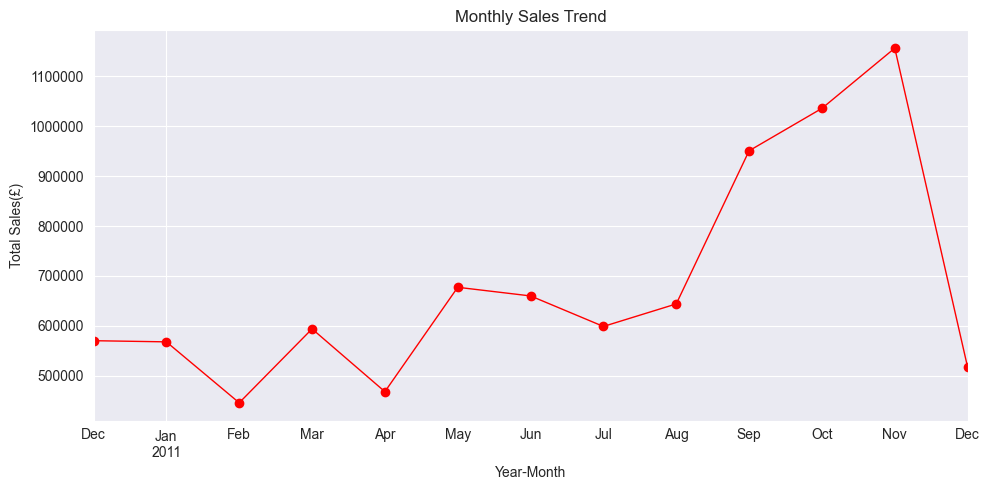

Best Month: 2011-11
Sales: £1,156,205.61


In [ ]:
#Monthly sales trend analysis
monthly_sales = df.groupby('YearMonth')['Sales'].sum()
display(monthly_sales)

#draw the line chart for monthly sales 
fig, ax = plt.subplots(figsize=(10, 5))

monthly_sales.plot(
    kind='line',
    color='red',
    linewidth=1,
    marker='o',
    ax=ax)
ax.ticklabel_format(style='plain', axis='y') # format x-axis labels as plain numbers


ax.set_title('Monthly Sales Trend')
ax.set_xlabel('Year-Month')
ax.set_ylabel('Total Sales(£)')   
plt.tight_layout()
plt.show()

best_month = monthly_sales.idxmax()
best_month_sales = monthly_sales.max()
print(f"Best Month: {best_month}")
print(f"Sales: £{best_month_sales:,.2f}")


Monthly Analysis: 
-The peak sales month was November and total sales reaching £1,156,205.61
-The sales showed a increase from September to November (Q4) followed by sharp decline in December. This drop may be attribute to the Christmas holiday season, customers likley completed their gift shopping and festival preparetion beform end of November.
Commendation: 
-Increase stock levels in Q4 to meet the demand
-Allocate higher promotion budget during Q4 to maximize the sales opportunities

Weekday
Monday       1363604.401
Tuesday      1697733.801
Wednesday    1584283.830
Thursday     1973015.730
Friday       1483080.811
Sunday        785490.321
Name: Sales, dtype: float64

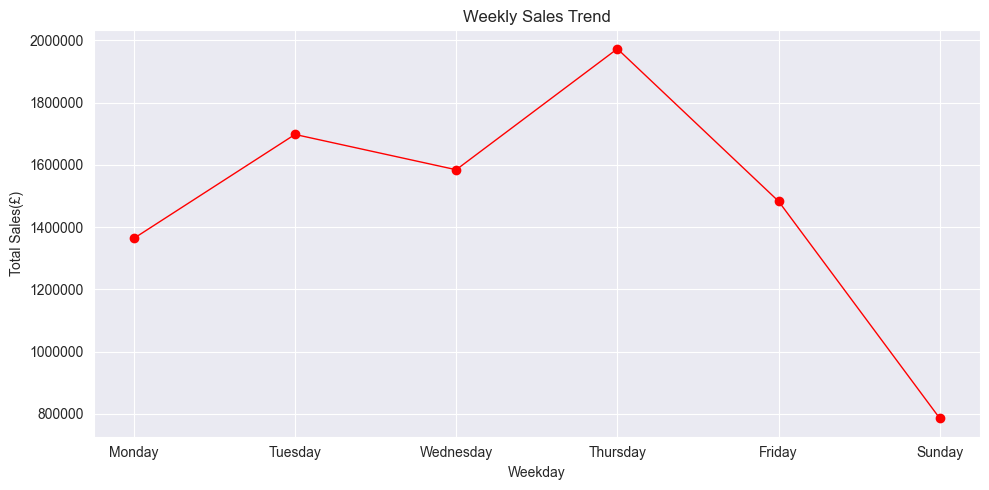

Best Weekday: Thursday
Sales: 1,973,015.73


Weekday
Monday       2863
Tuesday      3184
Wednesday    3455
Thursday     4032
Friday       2829
Sunday       2169
Name: InvoiceNo, dtype: int64

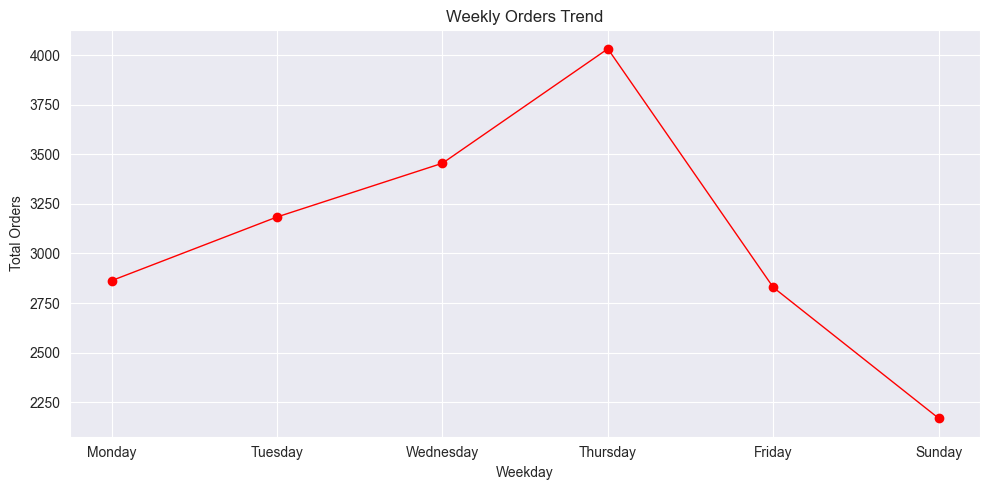

In [26]:
#Weekly sales trend analysis
Weekly_sales = df.groupby('Weekday')['Sales'].sum()
weekmap = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'} #dictionary
Weekly_sales.index = Weekly_sales.index.map(weekmap) # map the weekday numbers to names
display(Weekly_sales)

fig, ax = plt.subplots(figsize=(10, 5))

Weekly_sales.plot(
    kind='line',
    color='red',
    linewidth=1,
    marker='o',
    ax=ax)
ax.ticklabel_format(style='plain', axis='y') # format x-axis labels as plain numbers
ax.set_title("Weekly Sales Trend")
ax.set_xlabel("Weekday")
ax.set_ylabel("Total Sales(£)")
plt.tight_layout()
plt.show()

best_weekday = Weekly_sales.idxmax()
best_weekday_sales = Weekly_sales.max()
print(f"Best Weekday: {best_weekday}")
print(f"Sales: {best_weekday_sales:,.2f}")

Weekly_orders = df.groupby('Weekday')['InvoiceNo'].nunique()
Weekly_orders.index = Weekly_orders.index.map(weekmap) # map the weekday numbers to names
display(Weekly_orders)

fig, ax = plt.subplots(figsize=(10,5))

Weekly_orders.plot(
    kind='line',
    color='red',
    linewidth=1,
    marker='o'
)

ax.set_title("Weekly Orders Trend")
ax.set_xlabel("Weekday")
ax.set_ylabel("Total Orders")
plt.tight_layout()
plt.show()

best_weekday_orders = Weekly_orders.idxmax()
best_weekday_orders_count = Weekly_orders.max()


Weekly Analysis:
-Thursday was the best sales weekday
-Possible reason : People  purchasing product for weekend

Recommendation:
-Schedule social media and email campaigns for Thursday morning to capture customers
-Ensure stock levels and staffing are optimized to handle week peak

6. Products and Region Analysis

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Sales, dtype: float64

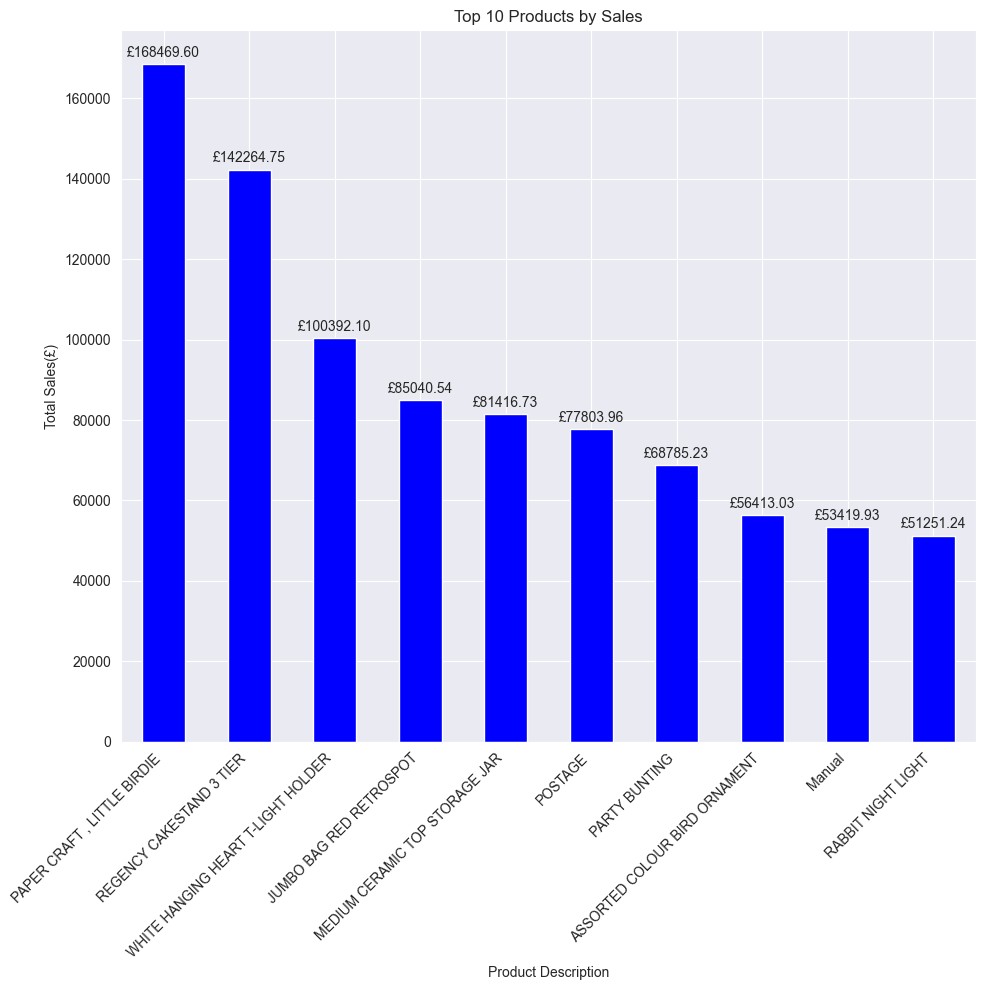

Best Product: PAPER CRAFT , LITTLE BIRDIE
Sales: 168,469.60


In [27]:
#Top 10 products by sales
top_products = df.groupby('Description')['Sales'].sum().nlargest(10)
display(top_products)

fig,ax = plt.subplots(figsize=(10,10))
bars = top_products.plot(
    kind='bar',
    color='blue',
    ax=ax
)
ax.bar_label(bars.containers[0], fmt='£%.2f', padding=3) # add data labels on top of the bars
ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Product Description")
ax.set_ylabel("Total Sales(£)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

best_product = top_products.idxmax()
best_product_sales = top_products.max()
print(f"Best Product: {best_product}")
print(f"Sales: {best_product_sales:,.2f}")



Product Analysis:
-Paper Craft , little birdle was the top sales product.
-Most of the top10 sales products were party related.
Recommendation:
-Ensure the stock levels of these top sales products.
-Launch more party related products and promotion.

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Sales, dtype: float64

The best sales  country is United Kingdom with sales of £7,285,024.64
The contribution of UK is 81.97% of total sales


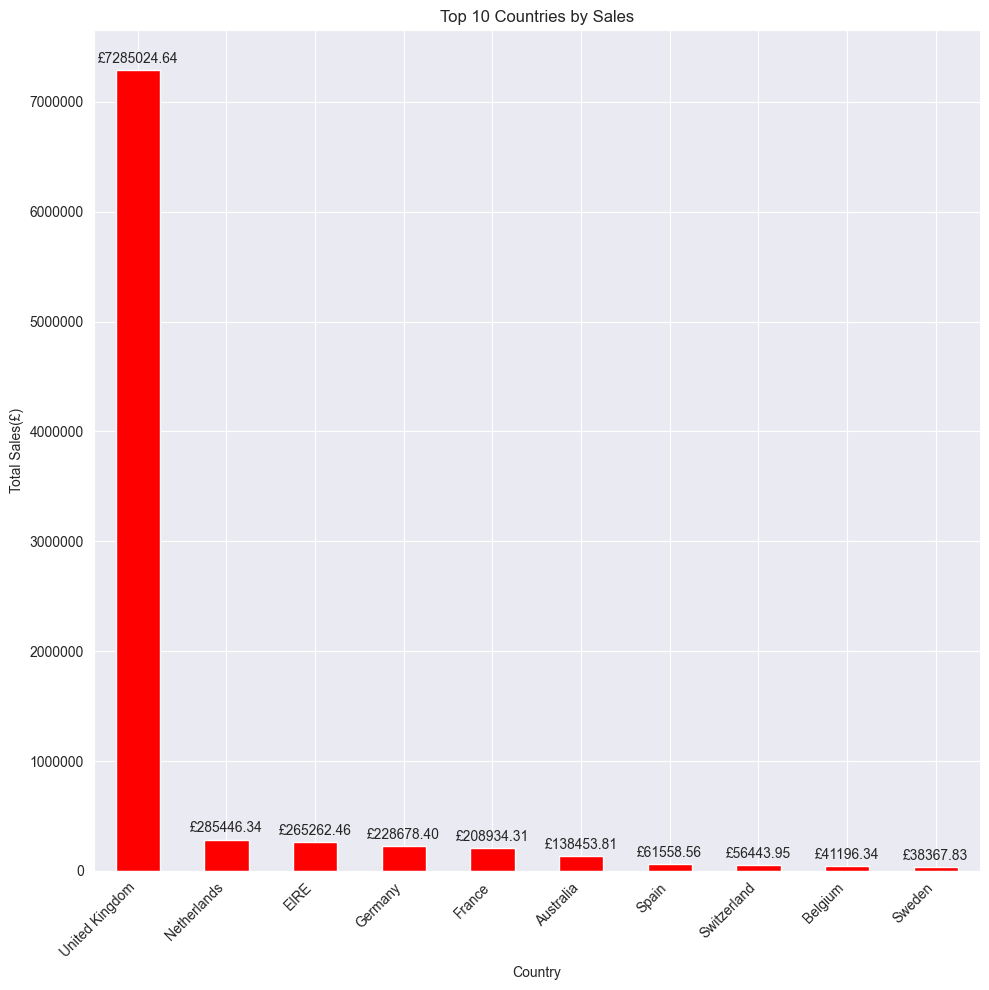

In [35]:
#Top 10 Countries by sales

top_countrys = df.groupby('Country')['Sales'].sum().nlargest(10)
display(top_countrys)

print(f"The best sales  country is {top_countrys.idxmax()} with sales of £{top_countrys.max():,.2f}")
print(f"The contribution of UK is {top_countrys['United Kingdom'] / total_sales * 100:.2f}% of total sales")
fig, ax = plt.subplots(figsize=(10,10))
bars=top_countrys.plot(
    kind='bar',
    color='red',
    ax=ax
)
ax.bar_label(bars.containers[0], fmt='£%.2f', padding=3) # add data labels on top of the bars
ax.ticklabel_format(style='plain', axis='y') # format y-axis labels as plain numbers
ax.set_title("Top 10 Countries by Sales")
ax.set_xlabel("Country")
ax.set_ylabel("Total Sales(£)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Region Analysis:
-Most of the product was saled in UK 
-Our product are more famous in european countries
Recommendation:
-Launch more capaigns in UK and european countries 

7. Customers Analysis

Top 10 customers by sales:



CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Sales, dtype: float64

Contribution of top 10 customers to total sales:
CustomerID
14646.0    3.15%
18102.0    2.92%
17450.0    2.19%
16446.0     1.9%
14911.0    1.62%
12415.0    1.41%
14156.0    1.32%
17511.0    1.02%
16029.0    0.91%
12346.0    0.87%
Name: Sales, dtype: str
Number of high-spending users: 434
Number of middle-spending users: 1735
Number of low-spending users: 2169
High-spending : 5461374.89
Middle-spending : 2731960.84
Low-spending : 693873.16
High-spending percentage : 61.45%


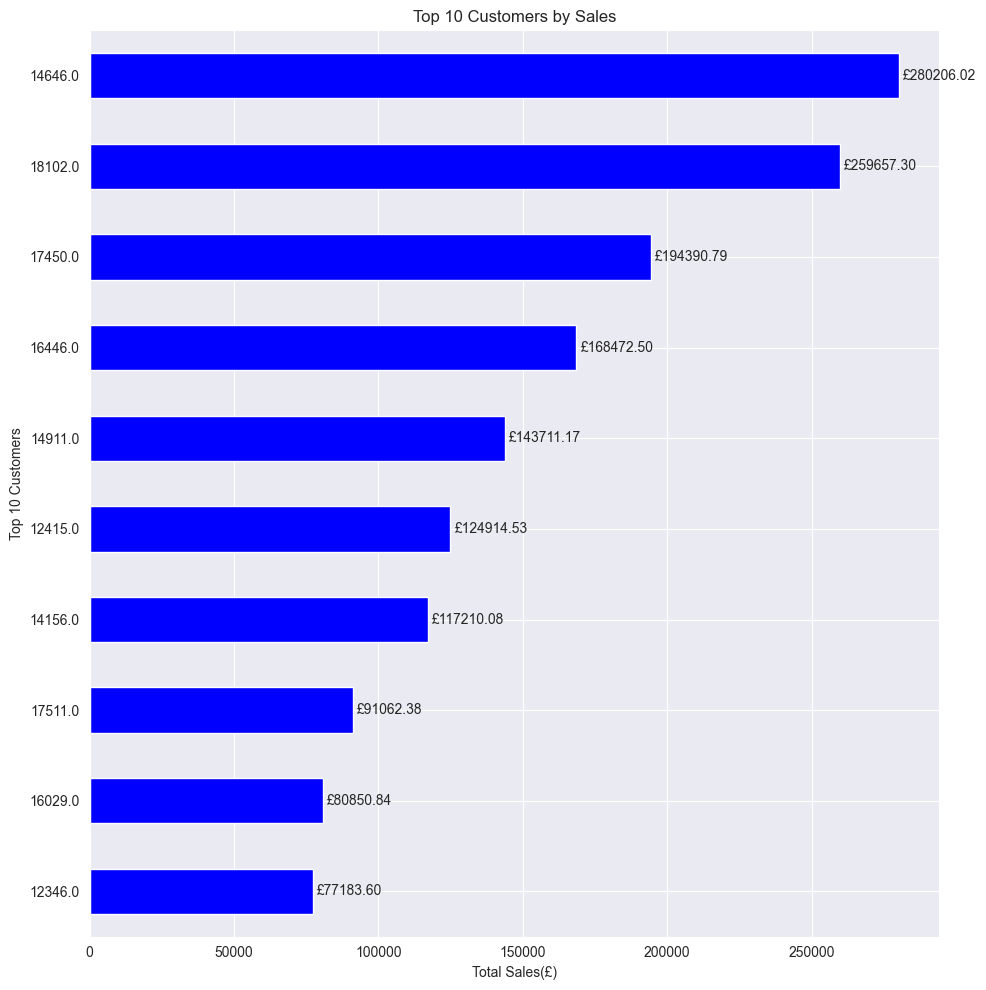

In [33]:
user_sales = df.groupby('CustomerID')['Sales'].sum()
top10_customer = user_sales.nlargest(10)
print("Top 10 customers by sales:\n")
display(top10_customer)

contrubution = top10_customer / total_sales * 100
print("Contribution of top 10 customers to total sales:")
print(contrubution.round(2).astype(str) + '%')
high_user = user_sales[user_sales > user_sales.quantile(0.9)]
mid_user = user_sales[(user_sales > user_sales.quantile(0.5)) & (user_sales <= user_sales.quantile(0.9))]
low_user = user_sales[user_sales <= user_sales.quantile(0.5)]
print(f"Number of high-spending users: {high_user.count()}")
print(f"Number of middle-spending users: {mid_user.count()}")
print(f"Number of low-spending users: {low_user.count()}")
print(f"High-spending : {high_user.sum().round(2)}")
print(f"Middle-spending : {mid_user.sum().round(2)}")
print(f"Low-spending : {low_user.sum().round(2)}")
print(f"High-spending percentage : {high_user.sum() / total_sales * 100:.2f}%")
fig, ax = plt.subplots(figsize=(10,10))
bars = top10_customer.plot(
    kind='barh',
    color='blue',
    ax=ax,
    
)
ax.bar_label(bars.containers[0], fmt='£%.2f', padding=3) # add data labels on top of the bars
ax.set_title("Top 10 Customers by Sales")
ax.set_xlabel("Total Sales(£)")
ax.set_ylabel("Top 10 Customers")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Customer Analysis:
-High spending user contributed 61.45% of the total sales
Recommendation:
Introduce VIP system to reward high-spending user and increase customer loyalty.

8. Conclusion
-Most of sales were in Q4, stock level should be ensure in Q4 and more campaigns should be launch in Q4.
-Most of sales were on Thursday, more marketing campaigns such as email and social media promotion should be launch in Wednesday evening or Thursday morning, also stock levels and staffing should be optimized to handle to week peak.
-Top 10 sales are mostly party-related product, we should focus on launching related product and promotion theme may be related.
-UK was our major sales country which contributed 81.97% of sales therefore we should launch more promotion in UK.
-Top 10% high-spending user contributed 61.45% of salse, VIP system should be introduced to reward them and increase customer loyalty.